# Tutorial 3: Horizontal denoising and integration on Mouse Brain dataset from 10x Visium 

In this tutorial, to assess STADIM’s ability to resolve fine anatomical structures, we analyze horizontally adjacent mouse whole-brain slices generated by the 10x Visium platform.   
We download the data via:  
Anterior: https://www.10xgenomics.com/datasets/mouse-brain-serial-section-1-sagittal-anterior-1-standard-1-1-0  
Posterior: https://www.10xgenomics.com/datasets/mouse-brain-serial-section-1-sagittal-posterior-1-standard-1-1-0

## Quick view data

In [1]:
import anndata as ad
import os

sample_ids = ['MBSS1SA', 'MBSS1SP']
data_dir = '/data2/xiaost/SODA/Data/MB/'

for i, s_id in enumerate(sample_ids):
    adata = ad.read_h5ad(os.path.join(data_dir, f'{s_id}.h5ad'))
    print(f'{s_id}')
    print(adata)

MBSS1SA
AnnData object with n_obs × n_vars = 2695 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'sample'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
MBSS1SP
AnnData object with n_obs × n_vars = 3355 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'sample'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


## Run STADIM

You can call the STADIM command directly in your terminal:
```bash
nohup stadim --input "./MBSS1SA.h5ad" "./MBSS1SP.h5ad" --save_dir ./MB_test --device "cuda:0" --monitor --seed 2026 --min_genes 0 --min_cells 10 --knn_c 6 --knn_e 10 --mnn_n 25 > ./MB_test.log 2>&1 &
```
and load the results into your Python environment for downstream analysis. The denoised expression matrix is conveniently stored within the `layers` attribute:
```python
import anndata as ad

adata = ad.read_h5ad('/MB_test/sdata.h5ad')

## The denoised gene expressionis is stored in adata.layers['STADIM']
print(adata)
```
or you can call STADIM within a Jupyter Notebook as follows:

In [2]:
import stadim

adata = stadim.run_STADIM(['/data2/xiaost/SODA/Data/MB/MBSS1SA.h5ad', '/data2/xiaost/SODA/Data/MB/MBSS1SP.h5ad'], 
                          save_preprocessed_h5ad=None, save_dir=None, 
                          sample_names=None, batch_key='sample', device='cuda:4', seed=2026, 
                          min_genes=0, min_cells=10, nhvgs=2000, dim=50, knn_c=6, knn_e=10, mnn_n=25,
                          batch_size=256, triplets_update_ratio=0.8, hard_triplets_ratio=0.7,
                          epochs=100, lr=1e-3, loss_mode='nb', beta_trip=0.1,
                          encoder_layers=[512, 256, 64], decoder_layers=[1000])

Results will be stored in adata.layers['STADIM']

=== 1. Begin read_data!
Detected multi-slice data, total 2 slices
  Slice 1: Using user-defined column 'sample' as sample
  Slice 1: Keeping existing sample label MBSS1SA
  Slice 2: Using user-defined column 'sample' as sample
  Slice 2: Keeping existing sample label MBSS1SP

Merging data...

Raw Merged Data: 6050 spots × 32285 genes
Unified Filtering (min_genes=0, min_cells=10)...
  → After Filtering: 6050 spots × 18330 genes
  ✓ Complete: Samples included: ['MBSS1SA', 'MBSS1SP']
  ✓ Complete: AnnData object with n_obs × n_vars = 6050 × 18330
    obs: 'in_tissue', 'array_row', 'array_col', 'sample'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'X_raw'

=== 2. Begin MY_preprocess!
== Selected 2000 HVGs across 2 slices

=== 3. Begin all_ap find neighbors!

=== 4. Begin pre_dataset!
{0: 'MBSS1SA', 1: 'MBSS1SP'}


Preparing triplet: 100%|██████████| 6050/6050 [00:00<00:00, 6788.32it/s]



=== 5. Begin IterableTripletDataset!
Initializing triplets...
IterableTripletDataset Initialized: 6050 anchors, batch_size=256

=== 6. Begin calculate_recommended_margin!
Calculating recommended margin (averaging over 5 runs)...

Margins from 5 runs: [15.0, 15.0, 15.0, 15.0, 15.0]
Final Recommended Margin: 15.0000

=== 7. Starting training...
Begin training: device=cuda:4


Training: 100%|██████████| 100/100 [02:29<00:00,  1.50s/it, recon=0.681, triplet=1.172, total=0.798]



=== 8. Generating denoised expression...
   Data size (1.11e+08) is within limits. Allocating memory for denoised data.

All processes finished! Total time: 2.99 mins.


In [3]:
print(adata)

AnnData object with n_obs × n_vars = 6050 × 18330
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'size_factor'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'
    uns: 'spatial', 'log1p', 'top_hvgs'
    obsm: 'spatial', 'S_scale', 'X_hvg_scale', 'X_pca', 'cell_names', 'STADIM'
    layers: 'X_raw', 'X_norm', 'X_log', 'STADIM', 'STADIM_withbatch'


## Analysis

In [4]:
import anndata as ad
import pandas as pd
import scanpy as sc 
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
plt.rcParams.update({
    'font.size': 16, 
    'axes.labelsize': 18,  
    'axes.titlesize': 18,  
    'xtick.labelsize': 16, 
    'ytick.labelsize': 16,  
    'legend.fontsize': 16,
})

my_colors = [
  '#c49c94', '#1f77b4', '#bcbd22', "#BCD896", '#9edae5', '#c7c7c7', # 0-5
  '#c5b0d5', '#2ca02c', '#17becf', '#aec7e8', '#ff9896', '#ff7f0e', # 6-11
  '#98df8a', '#e377c2', '#d62728', '#f7b6d3', "#6BBE92", '#8c564b', # 12-17
  '#FCC616', "#9b2626", '#d6616b', '#9467bd', '#dbdb8d', "#E97F5A", # 18-23
  '#ffbb78', '#e7969c', '#ffff99', "#637939", '#a55194', '#e7969c', # 24-29
]

In [5]:
s1, s2 = sample_ids[0], sample_ids[1]

new_spatial = adata.obsm['spatial'].copy().astype(float)

mask1 = adata.obs['sample'] == s1
coords1 = new_spatial[mask1]
width1 = coords1[:, 0].max() - coords1[:, 0].min()
new_spatial[mask1] -= [coords1[:, 0].min(), coords1[:, 1].min()]

mask2 = adata.obs['sample'] == s2
coords2 = new_spatial[mask2]
gap = 1 
new_spatial[mask2] -= [coords2[:, 0].min(), coords2[:, 1].min()]
new_spatial[mask2] += [width1 + gap, 0]

adata.obsm['spatial_joined'] = new_spatial

### Louvain

The following package needs to be installed in the environment:
```bash
pip install louvain python-igraph
```

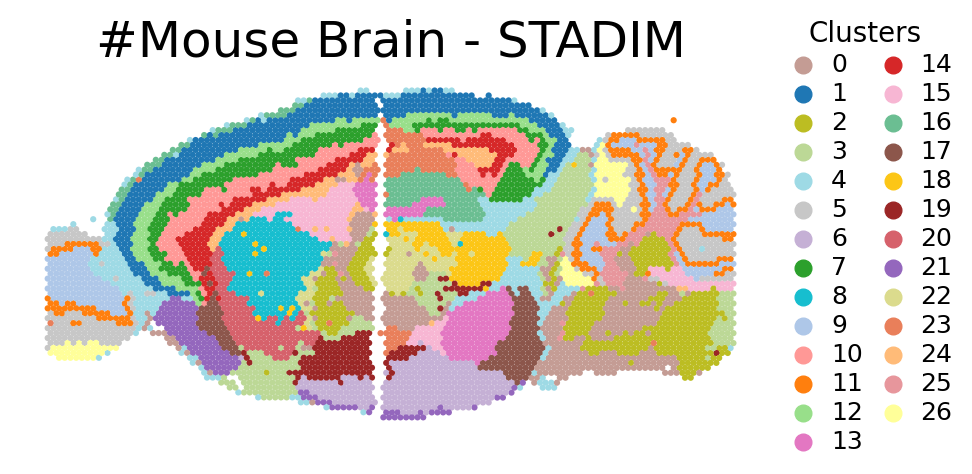

In [6]:
method = 'STADIM'
cluster_key = f"{method}_clusters"
sc.pp.neighbors(adata, use_rep=method, key_added=method)
sc.tl.louvain(adata, neighbors_key=method, key_added=cluster_key, resolution=0.8)
n_clusters = len(adata.obs[cluster_key].unique())

# if n_clusters==nnn:
adata.uns[f"{cluster_key}_colors"] = my_colors[:n_clusters]

fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.spatial(adata, color=cluster_key, spot_size=150, title=None, show=False, ax=ax, alpha_img=0.5, library_id=None,basis='spatial_joined')
ax.set_title(f"#Mouse Brain - STADIM", fontsize=36, pad=10)#fontweight='bold', 
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_aspect('equal')
ax.axis('off')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Clusters", title_fontsize=20, fontsize=18, handletextpad=0.1,
          ncol=2, loc='upper left', bbox_to_anchor=(0.98, 1.2), labelspacing=0.2, columnspacing=0.2, markerscale=2, frameon=False)

plt.tight_layout()
plt.show()